## Did the air bubbles have an effect?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import xarray as xr

sys.path.append('/Users/kjesta/Desktop/Master prosjekt/Master_code/Lab/')
from funcs import *
from processing_funcs import *
from analysis_funcs import *

import matplotlib.style as mplstyle
mplstyle.use(["ggplot", "fast"])

import warnings
warnings.filterwarnings("ignore")

sys.path.append('/Users/kjesta/Desktop/LABDATA/Processed_files/')

%load_ext autoreload
%autoreload 2

### f = 1.1 Hz

In [2]:
basepath = '/Users/kjesta/Desktop/LABDATA/Processed_files/'
f11a01r1 = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_r1_processed.csv'))
f11a01r2 = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_r2_processed.csv'))
f11a01r3 = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_r3_processed.csv'))

f11a02r1 = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_r1_processed.csv'))
f11a02r2 = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_r2_processed.csv'))
f11a02r3 = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_r3_processed.csv'))

f11a03r1 = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_r1_processed.csv'))
f11a03r2 = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_r2_processed.csv'))
f11a03r3 = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_r3_processed.csv'))

f11a01r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_nobub_r1_processed.csv'))
f11a01r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_nobub_r2_processed.csv'))
f11a01r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a01_p005_nobub_r3_processed.csv'))

f11a02r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_nobub_r1_processed.csv'))
f11a02r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_nobub_r2_processed.csv'))
f11a02r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a02_p005_nobub_r3_processed.csv'))

f11a03r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_nobub_r1_processed.csv'))
f11a03r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_nobub_r2_processed.csv'))
f11a03r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f11_a03_p005_nobub_r3_processed.csv'))

# Switch sign of elevation
for df in [f11a01r1, f11a01r2, f11a01r3, f11a02r1, f11a02r2, f11a02r3, f11a03r1, f11a03r2, f11a03r3,
           f11a01r1nobub, f11a01r2nobub, f11a01r3nobub, f11a02r1nobub, f11a02r2nobub, f11a02r3nobub,
           f11a03r1nobub, f11a03r2nobub, f11a03r3nobub]:
    df['P_0'] = -df['P_0']
    df['P_1'] = -df['P_1']
    df['P_2'] = -df['P_2']
    df['P_3'] = -df['P_3']

In [3]:
def make_dataset(df, freq):
    peaks_p0 = find_positive_peaks(freq, df, 'P_0')
    peaks_p3 = find_positive_peaks(freq, df, 'P_3')
    amp_P0 = np.mean(peaks_p0)
    amp_P3 = np.mean(peaks_p3)
    diff = amp_P0 - amp_P3
    return xr.Dataset({'peaks_P0': peaks_p0, 'peaks_P3': peaks_p3, 
                       'amp_P0': amp_P0, 'amp_P3': amp_P3, 'diff': diff}, 
                       attrs={'frequency': freq})

In [4]:
f11a01r1_ds = make_dataset(f11a01r1, 1.1)
f11a01r2_ds = make_dataset(f11a01r2, 1.1)
f11a01r3_ds = make_dataset(f11a01r3, 1.1)

f11a02r1_ds = make_dataset(f11a02r1, 1.1)
f11a02r2_ds = make_dataset(f11a02r2, 1.1)
f11a02r3_ds = make_dataset(f11a02r3, 1.1)

f11a03r1_ds = make_dataset(f11a03r1, 1.1)
f11a03r2_ds = make_dataset(f11a03r2, 1.1)
f11a03r3_ds = make_dataset(f11a03r3, 1.1)

f11a01r1nobub_ds = make_dataset(f11a01r1nobub, 1.1)
f11a01r2nobub_ds = make_dataset(f11a01r2nobub, 1.1)
f11a01r3nobub_ds = make_dataset(f11a01r3nobub, 1.1)

f11a02r1nobub_ds = make_dataset(f11a02r1nobub, 1.1)
f11a02r2nobub_ds = make_dataset(f11a02r2nobub, 1.1)
f11a02r3nobub_ds = make_dataset(f11a02r3nobub, 1.1)

f11a03r1nobub_ds = make_dataset(f11a03r1nobub, 1.1)
f11a03r2nobub_ds = make_dataset(f11a03r2nobub, 1.1)
f11a03r3nobub_ds = make_dataset(f11a03r3nobub, 1.1)

In [5]:
diff_a01 = [f11a01r1_ds['diff'], f11a01r2_ds['diff'], f11a01r3_ds['diff']]
diff_a02 = [f11a02r1_ds['diff'], f11a02r2_ds['diff'], f11a02r3_ds['diff']]
diff_a03 = [f11a03r1_ds['diff'], f11a03r2_ds['diff'], f11a03r3_ds['diff']]

diff_a01_nobub = [f11a01r1nobub_ds['diff'], f11a01r2nobub_ds['diff'], f11a01r3nobub_ds['diff']]
diff_a02_nobub = [f11a02r1nobub_ds['diff'], f11a02r2nobub_ds['diff'], f11a02r3nobub_ds['diff']]
diff_a03_nobub = [f11a03r1nobub_ds['diff'], f11a03r2nobub_ds['diff'], f11a03r3nobub_ds['diff']]

Text(0.5, 1.0, 'f=1.1 Hz')

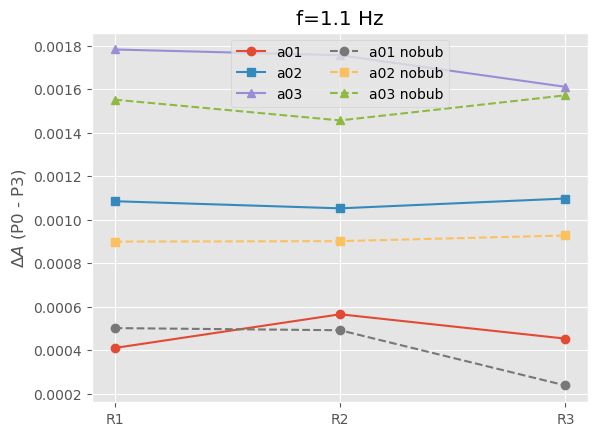

In [6]:
runs = ['R1', 'R2', 'R3']
plt.plot(runs, diff_a01, 'o-', label='a01')
plt.plot(runs, diff_a02, 's-', label='a02')
plt.plot(runs, diff_a03, '^-', label='a03')
plt.plot(runs, diff_a01_nobub, 'o--', label='a01 nobub')
plt.plot(runs, diff_a02_nobub, 's--', label='a02 nobub')
plt.plot(runs, diff_a03_nobub, '^--', label='a03 nobub')
plt.legend(ncol=2)
plt.ylabel(r'$\Delta A$ (P0 - P3)')
plt.title('f=1.1 Hz')

### f = 1.3 Hz

In [7]:
f13a01r1 = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_r1_processed.csv'))
f13a01r2 = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_r2_processed.csv'))
f13a01r3 = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_r3_processed.csv'))

f13a02r1 = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_r1_processed.csv'))
f13a02r2 = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_r2_processed.csv'))
f13a02r3 = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_r3_processed.csv'))

f13a03r1 = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_r1_processed.csv'))
f13a03r2 = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_r2_processed.csv'))
f13a03r3 = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_r3_processed.csv'))

f13a01r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_nobub_r1_processed.csv'))
f13a01r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_nobub_r2_processed.csv'))
f13a01r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a01_p005_nobub_r3_processed.csv'))

f13a02r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_nobub_r1_processed.csv'))
f13a02r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_nobub_r2_processed.csv'))
f13a02r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a02_p005_nobub_r3_processed.csv'))

f13a03r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_nobub_r1_processed.csv'))
f13a03r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_nobub_r2_processed.csv'))
f13a03r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f13_a03_p005_nobub_r3_processed.csv'))

# Switch sign of elevation
for df in [f13a01r1, f13a01r2, f13a01r3, f13a02r1, f13a02r2, f13a02r3, f13a03r1, f13a03r2, f13a03r3,
           f13a01r1nobub, f13a01r2nobub, f13a01r3nobub, f13a02r1nobub, f13a02r2nobub, f13a02r3nobub,
           f13a03r1nobub, f13a03r2nobub, f13a03r3nobub]:
    df['P_0'] = -df['P_0']
    df['P_1'] = -df['P_1']
    df['P_2'] = -df['P_2']
    df['P_3'] = -df['P_3']

In [8]:
f13a01r1_ds = make_dataset(f13a01r1, 1.3)
f13a01r2_ds = make_dataset(f13a01r2, 1.3)
f13a01r3_ds = make_dataset(f13a01r3, 1.3)

f13a02r1_ds = make_dataset(f13a02r1, 1.3)
f13a02r2_ds = make_dataset(f13a02r2, 1.3)
f13a02r3_ds = make_dataset(f13a02r3, 1.3)

f13a03r1_ds = make_dataset(f13a03r1, 1.3)
f13a03r2_ds = make_dataset(f13a03r2, 1.3)
f13a03r3_ds = make_dataset(f13a03r3, 1.3)

f13a01r1nobub_ds = make_dataset(f13a01r1nobub, 1.3)
f13a01r2nobub_ds = make_dataset(f13a01r2nobub, 1.3)
f13a01r3nobub_ds = make_dataset(f13a01r3nobub, 1.3)

f13a02r1nobub_ds = make_dataset(f13a02r1nobub, 1.3)
f13a02r2nobub_ds = make_dataset(f13a02r2nobub, 1.3)
f13a02r3nobub_ds = make_dataset(f13a02r3nobub, 1.3)

f13a03r1nobub_ds = make_dataset(f13a03r1nobub, 1.3)
f13a03r2nobub_ds = make_dataset(f13a03r2nobub, 1.3)
f13a03r3nobub_ds = make_dataset(f13a03r3nobub, 1.3)

In [9]:
diff_a01 = [f13a01r1_ds['diff'], f13a01r2_ds['diff'], f13a01r3_ds['diff']]
diff_a02 = [f13a02r1_ds['diff'], f13a02r2_ds['diff'], f13a02r3_ds['diff']]
diff_a03 = [f13a03r1_ds['diff'], f13a03r2_ds['diff'], f13a03r3_ds['diff']]

diff_a01_nobub = [f13a01r1nobub_ds['diff'], f13a01r2nobub_ds['diff'], f13a01r3nobub_ds['diff']]
diff_a02_nobub = [f13a02r1nobub_ds['diff'], f13a02r2nobub_ds['diff'], f13a02r3nobub_ds['diff']]
diff_a03_nobub = [f13a03r1nobub_ds['diff'], f13a03r2nobub_ds['diff'], f13a03r3nobub_ds['diff']]

Text(0.5, 1.0, 'f=1.3 Hz')

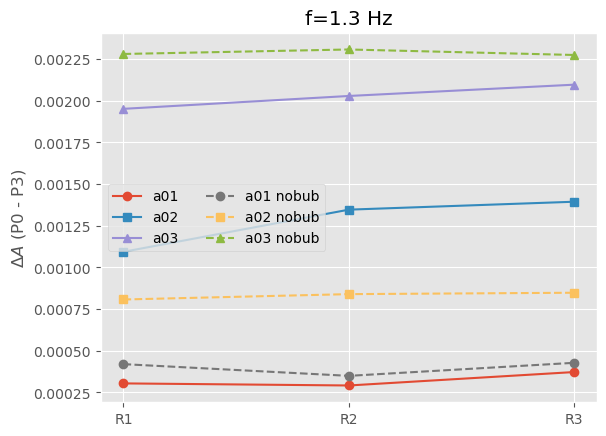

In [10]:
runs = ['R1', 'R2', 'R3']
plt.plot(runs, diff_a01, 'o-', label='a01')
plt.plot(runs, diff_a02, 's-', label='a02')
plt.plot(runs, diff_a03, '^-', label='a03')
plt.plot(runs, diff_a01_nobub, 'o--', label='a01 nobub')
plt.plot(runs, diff_a02_nobub, 's--', label='a02 nobub')
plt.plot(runs, diff_a03_nobub, '^--', label='a03 nobub')
plt.legend(ncol=2)
plt.ylabel(r'$\Delta A$ (P0 - P3)')
plt.title('f=1.3 Hz')

### f = 1.5 Hz

In [11]:
f15a01r1 = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_r1_processed.csv'))
f15a01r2 = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_r2_processed.csv'))
f15a01r3 = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_r3_processed.csv'))

f15a02r1 = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_r1_processed.csv'))
f15a02r2 = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_r2_processed.csv'))
f15a02r3 = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_r3_processed.csv'))

f15a03r1 = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_r1_processed.csv'))
f15a03r2 = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_r2_processed.csv'))
f15a03r3 = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_r3_processed.csv'))

f15a01r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_nobub_r1_processed.csv'))
f15a01r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_nobub_r2_processed.csv'))
f15a01r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a01_p005_nobub_r3_processed.csv'))

f15a02r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_nobub_r1_processed.csv'))
f15a02r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_nobub_r2_processed.csv'))
f15a02r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a02_p005_nobub_r3_processed.csv'))

f15a03r1nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_nobub_r1_processed.csv'))
f15a03r2nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_nobub_r2_processed.csv'))
f15a03r3nobub = pd.read_csv(os.path.join(basepath, '20cm_f15_a03_p005_nobub_r3_processed.csv'))

# Switch sign of elevation
for df in [f15a01r1, f15a01r2, f15a01r3, f15a02r1, f15a02r2, f15a02r3, f15a03r1, f15a03r2, f15a03r3,
           f15a01r1nobub, f15a01r2nobub, f15a01r3nobub, f15a02r1nobub, f15a02r2nobub, f15a02r3nobub,
           f15a03r1nobub, f15a03r2nobub, f15a03r3nobub]:
    df['P_0'] = -df['P_0']
    df['P_1'] = -df['P_1']
    df['P_2'] = -df['P_2']
    df['P_3'] = -df['P_3']

In [12]:
f15a01r1_ds = make_dataset(f15a01r1, 1.5)
f15a01r2_ds = make_dataset(f15a01r2, 1.5)
f15a01r3_ds = make_dataset(f15a01r3, 1.5)

f15a02r1_ds = make_dataset(f15a02r1, 1.5)
f15a02r2_ds = make_dataset(f15a02r2, 1.5)
f15a02r3_ds = make_dataset(f15a02r3, 1.5)

f15a03r1_ds = make_dataset(f15a03r1, 1.5)
f15a03r2_ds = make_dataset(f15a03r2, 1.5)
f15a03r3_ds = make_dataset(f15a03r3, 1.5)

f15a01r1nobub_ds = make_dataset(f15a01r1nobub, 1.5)
f15a01r2nobub_ds = make_dataset(f15a01r2nobub, 1.5)
f15a01r3nobub_ds = make_dataset(f15a01r3nobub, 1.5)

f15a02r1nobub_ds = make_dataset(f15a02r1nobub, 1.5)
f15a02r2nobub_ds = make_dataset(f15a02r2nobub, 1.5)
f15a02r3nobub_ds = make_dataset(f15a02r3nobub, 1.5)

f15a03r1nobub_ds = make_dataset(f15a03r1nobub, 1.5)
f15a03r2nobub_ds = make_dataset(f15a03r2nobub, 1.5)
f15a03r3nobub_ds = make_dataset(f15a03r3nobub, 1.5)

In [13]:
diff_a01 = [f15a01r1_ds['diff'], f15a01r2_ds['diff'], f15a01r3_ds['diff']]
diff_a02 = [f15a02r1_ds['diff'], f15a02r2_ds['diff'], f15a02r3_ds['diff']]
diff_a03 = [f15a03r1_ds['diff'], f15a03r2_ds['diff'], f15a03r3_ds['diff']]

diff_a01_nobub = [f15a01r1nobub_ds['diff'], f15a01r2nobub_ds['diff'], f15a01r3nobub_ds['diff']]
diff_a02_nobub = [f15a02r1nobub_ds['diff'], f15a02r2nobub_ds['diff'], f15a02r3nobub_ds['diff']]
diff_a03_nobub = [f15a03r1nobub_ds['diff'], f15a03r2nobub_ds['diff'], f15a03r3nobub_ds['diff']]

Text(0.5, 1.0, 'f=1.5 Hz')

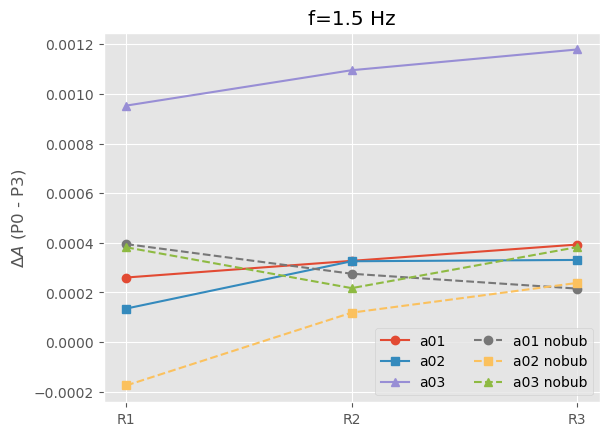

In [14]:
runs = ['R1', 'R2', 'R3']
plt.plot(runs, diff_a01, 'o-', label='a01')
plt.plot(runs, diff_a02, 's-', label='a02')
plt.plot(runs, diff_a03, '^-', label='a03')
plt.plot(runs, diff_a01_nobub, 'o--', label='a01 nobub')
plt.plot(runs, diff_a02_nobub, 's--', label='a02 nobub')
plt.plot(runs, diff_a03_nobub, '^--', label='a03 nobub')
plt.legend(ncol=2)
plt.ylabel(r'$\Delta A$ (P0 - P3)')
plt.title('f=1.5 Hz')